# Density estimation - Kernel density estimator

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from scipy.stats import norm

In [2]:
n = 200
n_component1 = int(0.1 * n)
n_component2 = n - n_component1

samples = np.concatenate([
    np.random.normal(loc=10, scale=1, size=n_component1),
    np.random.normal(loc=5, scale=1, size=n_component2),
])
np.random.shuffle(samples)

In [3]:
kde = KernelDensity(kernel='gaussian')
kde.fit(samples.reshape(-1, 1))

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",1.0
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None


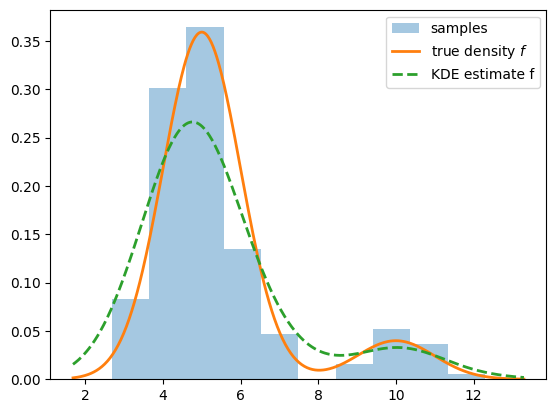

In [4]:
x = np.linspace(samples.min() - 1, samples.max() + 1, 500)

real_pdf = lambda x: 0.1 * norm.pdf(x, loc=10, scale=1) + 0.9 * norm.pdf(x, loc=5, scale=1)
f_true = real_pdf(x)

f_hat = np.exp(kde.score_samples(x.reshape(-1, 1)))

fig, ax = plt.subplots()
ax.hist(samples, density=True, alpha=0.4, label="samples")
ax.plot(x, f_true, label="true density $f$", linewidth=2)
ax.plot(x, f_hat, linestyle="--", label=r"KDE estimate f", linewidth=2)
ax.legend()
plt.show()

In [5]:
x = np.arange(2,13)

MSE = np.average((real_pdf(x) - np.exp(kde.score_samples(x.reshape(-1, 1))))**2)
print(MSE)

0.0014939473923115038


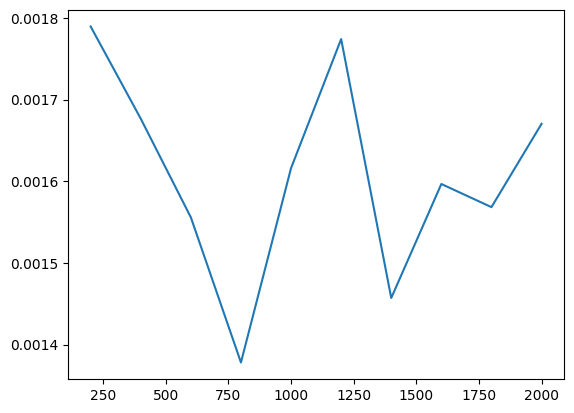

In [6]:
MSEs = []

for n in range(200, 2001, 200):
    # Generate samples
    n_component1 = int(0.1 * n)
    n_component2 = n - n_component1
    samples = np.concatenate([
        np.random.normal(loc=10, scale=1, size=n_component1),
        np.random.normal(loc=5, scale=1, size=n_component2),
    ])
    np.random.shuffle(samples)

    # Fit KDE
    kde = KernelDensity(kernel='gaussian')
    kde.fit(samples.reshape(-1, 1))

    # Get MSE score
    x = np.arange(2,13)

    MSE = np.average((real_pdf(x) - np.exp(kde.score_samples(x.reshape(-1, 1))))**2)
    MSEs.append(MSE)
plt.plot(list(range(200, 2001, 200)), MSEs)

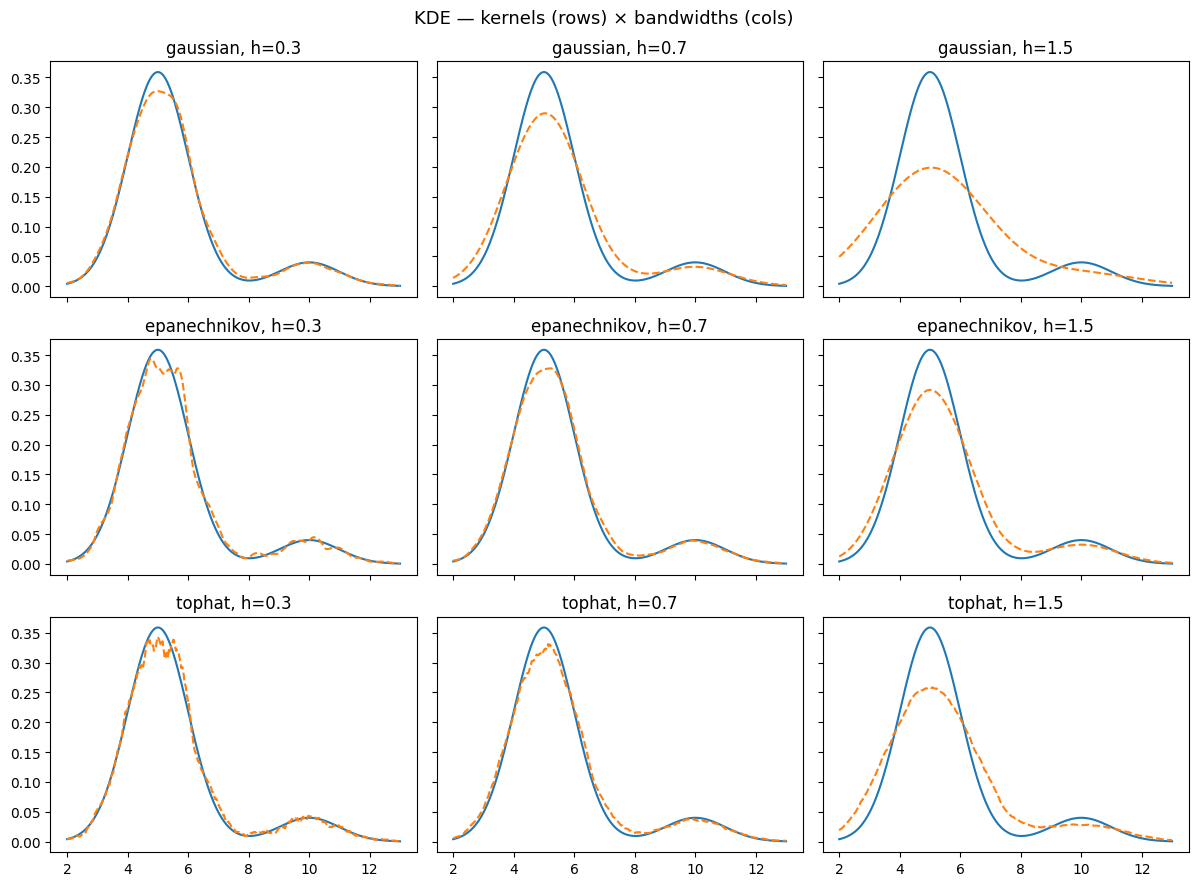

In [7]:
kernels = ['gaussian', 'epanechnikov', 'tophat']
bandwidths = [0.3, 0.7, 1.5]

x_plot = np.linspace(2, 13, 500)
f_true = real_pdf(x_plot)

fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
fig.suptitle("KDE — kernels (rows) × bandwidths (cols)", fontsize=13)

for i, kernel in enumerate(kernels):
    for j, bw in enumerate(bandwidths):
        ax = axes[i, j]

        kde_ = KernelDensity(kernel=kernel, bandwidth=bw)
        kde_.fit(samples.reshape(-1, 1))
        f_hat = np.exp(kde_.score_samples(x_plot.reshape(-1, 1)))

        ax.plot(x_plot, f_true, linewidth=1.5)
        ax.plot(x_plot, f_hat, linestyle="--", linewidth=1.5)
        ax.set_title(f"{kernel}, h={bw}")

plt.tight_layout()
plt.show()

## Task 2 - sampling from the fitted KDE


The second task compares the original KDE with a KDE fitted to an artificial sample generated from the first KDE. If the artificial sample is large, both estimators should be close because the artificial data are drawn from the same smoothed empirical distribution.


In [8]:
from sklearn.neighbors import KernelDensity


def mixture_pdf(x):
    return 0.9 * norm.pdf(x, loc=5, scale=1) + 0.1 * norm.pdf(x, loc=10, scale=1)


def sample_mixture(n, random_state=42):
    local_rng = np.random.default_rng(random_state)
    component = local_rng.binomial(1, 0.1, size=n)
    return np.where(
        component == 1,
        local_rng.normal(10, 1, size=n),
        local_rng.normal(5, 1, size=n),
    )


def kde_density(train, x_eval, bandwidth=0.4):
    kde_model = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(train.reshape(-1, 1))
    return np.exp(kde_model.score_samples(x_eval.reshape(-1, 1)))


def sample_from_kde(train, k=5000, bandwidth=0.4, random_state=42):
    local_rng = np.random.default_rng(random_state)
    centers = local_rng.choice(train, size=k, replace=True)
    noise = local_rng.normal(0, bandwidth, size=k)
    return centers + noise


X_base = sample_mixture(200, random_state=123)
x_eval = np.random.default_rng(123).uniform(2, 12, size=1000)
true_eval = mixture_pdf(x_eval)

method1 = kde_density(X_base, x_eval, bandwidth=0.4)
for k_artificial in [500, 2000, 10000]:
    X_art = sample_from_kde(X_base, k=k_artificial, bandwidth=0.4, random_state=k_artificial)
    method2 = kde_density(X_art, x_eval, bandwidth=0.4)
    print(
        f"k={k_artificial:5d}",
        "MSE method 1:", np.mean((true_eval - method1) ** 2),
        "MSE method 2:", np.mean((true_eval - method2) ** 2),
        "distance between methods:", np.mean((method1 - method2) ** 2),
    )


k=  500 MSE method 1: 0.0002427732465153831 MSE method 2: 0.00020306838724770608 distance between methods: 0.00010971785553232889
k= 2000 MSE method 1: 0.0002427732465153831 MSE method 2: 0.0002622546777903298 distance between methods: 7.245007468622976e-05
k=10000 MSE method 1: 0.0002427732465153831 MSE method 2: 0.0004807399893788918 distance between methods: 0.0001020986195949624


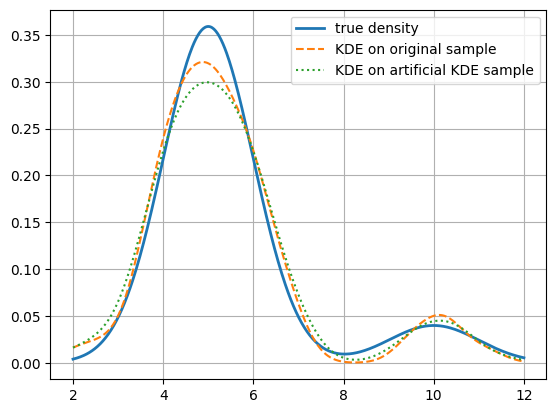

In [9]:
x_plot = np.linspace(2, 12, 500)
X_art = sample_from_kde(X_base, k=5000, bandwidth=0.4, random_state=99)
plt.plot(x_plot, mixture_pdf(x_plot), label="true density", linewidth=2)
plt.plot(x_plot, kde_density(X_base, x_plot, 0.4), "--", label="KDE on original sample")
plt.plot(x_plot, kde_density(X_art, x_plot, 0.4), ":", label="KDE on artificial KDE sample")
plt.legend()
plt.grid(True)
plt.show()


## Task 3 - Naive Bayes density variants and LDA


In [10]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.datasets import load_breast_cancer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler


class KDEFeatureNaiveBayes(BaseEstimator, ClassifierMixin):
    def __init__(self, bandwidth=0.5):
        self.bandwidth = bandwidth

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.log_priors_ = {}
        self.models_ = {}
        for cls in self.classes_:
            X_cls = X[y == cls]
            self.log_priors_[cls] = np.log(len(X_cls) / len(X))
            self.models_[cls] = [
                KernelDensity(kernel="gaussian", bandwidth=self.bandwidth).fit(X_cls[:, j:j + 1])
                for j in range(X.shape[1])
            ]
        return self

    def predict(self, X):
        scores = []
        for cls in self.classes_:
            log_density = np.full(X.shape[0], self.log_priors_[cls])
            for j, model in enumerate(self.models_[cls]):
                log_density += model.score_samples(X[:, j:j + 1])
            scores.append(log_density)
        return self.classes_[np.argmax(np.vstack(scores), axis=0)]


data = load_breast_cancer()
X = data.data[:, :10]  # quantitative variables; first 10 keep KDE computation cheap
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

methods = {
    "KDE Naive Bayes": make_pipeline(StandardScaler(), KDEFeatureNaiveBayes(bandwidth=0.4)),
    "Gaussian Naive Bayes": make_pipeline(StandardScaler(), GaussianNB()),
    "Discretized Naive Bayes": make_pipeline(
        KBinsDiscretizer(n_bins=6, encode="ordinal", strategy="quantile"),
        CategoricalNB(),
    ),
    "LDA": make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()),
}

for name, model in methods.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{name:25s} accuracy={accuracy_score(y_test, pred):.4f}")


KDE Naive Bayes           accuracy=0.9415
Gaussian Naive Bayes      accuracy=0.9181
Discretized Naive Bayes   accuracy=0.9298
LDA                       accuracy=0.9474


C:\Users\muric\Desktop\Universities\WUT_MASTERS\AML\labs\task1\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


KDE Naive Bayes is flexible but still assumes conditional independence across features. Gaussian Naive Bayes is more restrictive because each class-conditional feature density is Gaussian. Discretized Naive Bayes depends strongly on binning. LDA models a shared covariance matrix and can perform well when the class boundary is close to linear.
